# Introduction to Precipitation-based Climate Indices

This notebook demonstrates how to compute and visualize **precipitation-based climate indices** from CMIP6 datasets using the `earthkit-climate` and `xclim` packages.

We use:

- **Precipitation-based indices**:
  - *SDII*: Simple Daily Intensity Index (average precipitation on wet days)
  - *CWD*: Consecutive Wet Days (max number of wet days in a row)

We load **ACCESS-CM2 CMIP6 data** for both *historical* and *SSP585* scenarios.

In [ ]:
import warnings
from typing import Any, List, Union

import cartopy.crs as ccrs
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt
import xarray as xr

from earthkit.climate.indicators import precipitation

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)


def plot_climatology(
    figure: Any, data: xr.DataArray, row: int, col: int, title: str, cmap: Union[str, List[str]], units: str
) -> None:
    """
    Compute and plot the temporal mean of a dataset on a map.

    Parameters
    ----------
    figure : Any
        The figure or layout object where the map will be added.
    data : xarray.DataArray
        The input data containing a 'time' dimension to calculate the climatology.
    row : int
        Row index in the figure grid.
    col : int
        Column index in the figure grid.
    title : str
        Title for the specific map plot.
    cmap : str or list of str
        Color map name or list of colors for the plot style.
    units : str
        Units of the data for styling and legend labeling.

    Returns
    -------
    None
        The function modifies the `figure` object in place and does not return a value.
    """
    # Compute climatology (mean over time)
    climatology: xr.DataArray = data.mean("time")

    # Define style and plot
    # 'ekp' seems to be the library providing the Style and mapping tools
    style = ekp.styles.Style(colors=cmap, units=units)

    # The domain is now explicitly defined within the function
    map_plot = figure.add_map(row=row, column=col, domain=[-7.5, 0, 35.8, 40.2])

    map_plot.quickplot(climatology, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.title(title)
    map_plot.legend(location="right")

## Loading CMIP6 data

We’ll use *daily gridded data* from the ACCESS-CM2 model for precipitation (`pr`), for both historical and SSP585 future scenarios.


In [2]:
# Load precipitation
pr_hist = ekd.from_source("earthkit-climate-sample", "pr_ACCESS-CM2_historical_reference").to_xarray()
pr_ssp585 = ekd.from_source("earthkit-climate-sample", "pr_ACCESS-CM2_ssp585_far_future").to_xarray()

## Inspect and visualize the raw data

Before computing indices, let’s plot an example grid to see how the raw precipitation looks.


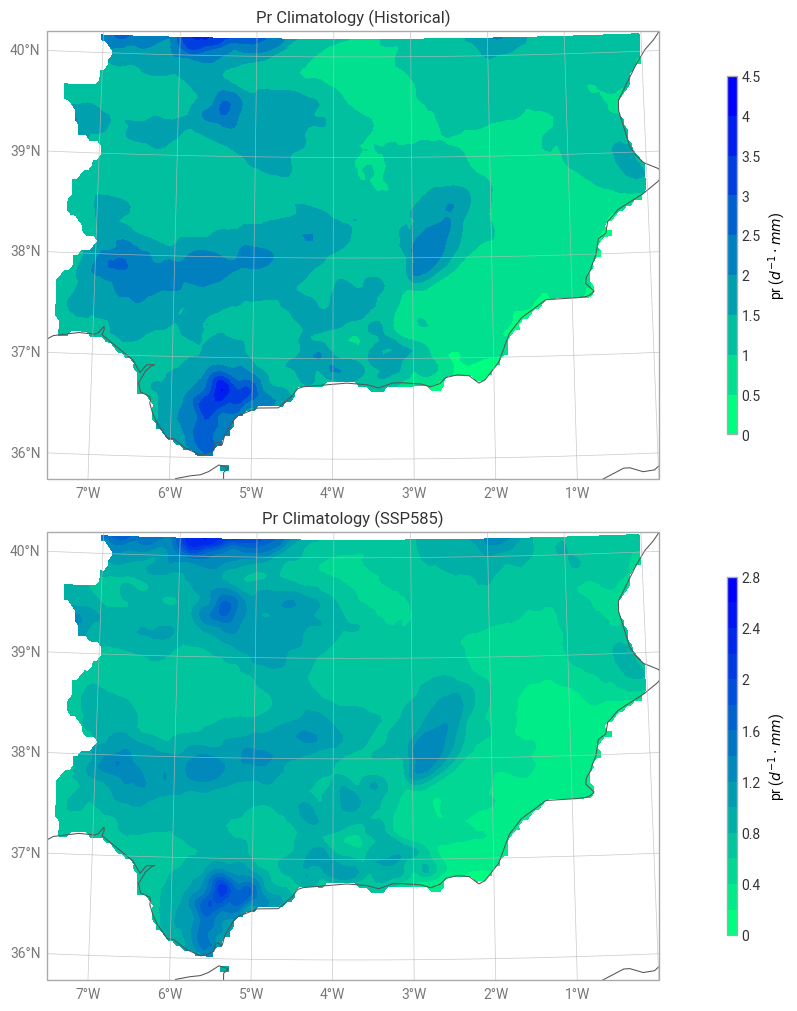

In [ ]:
# Create the figure with 2x1 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0), rows=2, columns=1, size=(15, 10)
)

# HISTORICAL (row 0)
plot_climatology(figure, pr_hist, 0, 0, "pr Climatology (Historical)", "winter_r", "mm/day")

# SSP585 (row 1)
plot_climatology(figure, pr_ssp585, 1, 0, "pr Climatology (SSP585)", "winter_r", "mm/day")

# Final layout
figure.show()

## Compute Simple Daily Intensity Index (SDII)

**SDII** measures the average precipitation amount on wet days (days with precipitation ≥ 1mm). We'll compute it for the SSP585 far-future scenario.


In [ ]:
# Compute SDII
sdii = precipitation.daily_pr_intensity(pr_ssp585)
sdii

<xarray.DataArray 'sdii' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B ...
Attributes:
    units:          mm d-1
    cell_methods:   
    history:        [2026-03-20 16:02:22] sdii: SDII(pr=pr, thresh='1 mm/day'...
    standard_name:  lwe_thickness_of_precipitation_amount
    long_name:      Average precipitation during days with daily precipitatio...
    description:    Annual simple daily intensity index (sdii) or annual aver...

## Compute Consecutive Wet Days (CWD)

**CWD** calculates the maximum number of consecutive days with precipitation ≥ 1mm per period (annually in this case).


In [ ]:
# Compute CWD
cwd = precipitation.maximum_consecutive_wet_days(pr_ssp585)
cwd

<xarray.DataArray 'cwd' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(1, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B ...
Attributes:
    units:          days
    cell_methods:    time: sum over days
    history:        [2026-03-20 16:02:23] cwd: CWD(pr=pr, thresh='1 mm/day', ...
    standard_name:  number_of_days_with_lwe_thickness_of_precipitation_amount...
    long_name:      Maximum consecutive days with daily precipitation at or a...
    description:    Annual maximum number of consecutive days with daily prec...

## Visualization of Precipitation Indices

Let’s visualize the climatologies (average across years) of these precipitation indices.


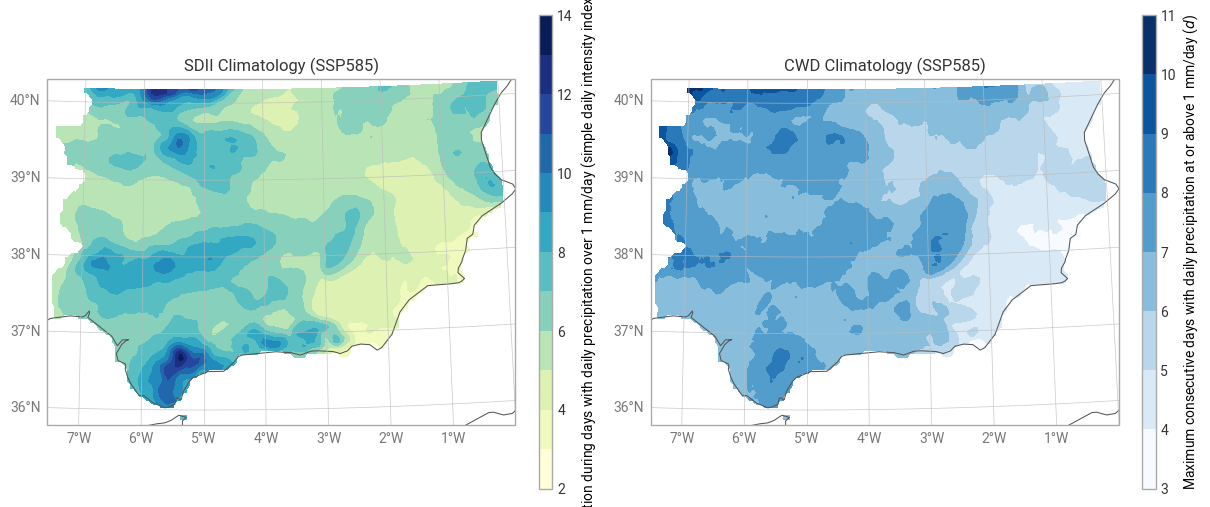

In [ ]:
# Create the figure with 1x2 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-5, central_latitude=43), rows=1, columns=2, size=(12, 6)
)

# Plot SDII
plot_climatology(figure, sdii, 0, 0, "SDII Climatology (SSP585)", "YlGnBu", "mm d-1")

# Plot CWD
plot_climatology(figure, cwd, 0, 1, "CWD Climatology (SSP585)", "Blues", "days")

# Final layout
figure.show()